In [21]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms

In [22]:
import os
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
from torchvision import transforms
import torch
import torchvision.transforms.functional as TF
import random
from natsort import natsorted
import platform

class SegmentationDataset(Dataset):
    def __init__(self, dataset_type, color_map=None, augment=False):
        base_dir = r"C:/My Files/Semester4TUM/Developed Dataset/Prepared Dataset for Thesis - fixed class imbalance"

        if dataset_type not in ["train", "val", "test"]:
            raise ValueError("dataset_type must be 'train', 'val', or 'test'")

        self.image_dir = os.path.join(base_dir, dataset_type, "image")
        self.mask_dir = os.path.join(base_dir, dataset_type, "mask")

        self.image_filenames = natsorted(os.listdir(self.image_dir))
        self.mask_filenames = natsorted(os.listdir(self.mask_dir))

        self.color_map = color_map
        self.augment = augment

        self.transform_image = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_filenames[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_filenames[idx])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("RGB")

        if self.augment:
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)
            if random.random() > 0.5:
                image = TF.vflip(image)
                mask = TF.vflip(mask)

        image = self.transform_image(image)

        mask_np = np.array(mask)
        mask_indices = np.zeros(mask_np.shape[:2], dtype=np.int64)

        found_colors = set()

        for rgb, class_idx in self.color_map.items():
            match = np.all(mask_np == rgb, axis=-1)
            mask_indices[match] = class_idx
            found_colors.add(rgb)

        unique_colors_in_mask = np.unique(mask_np.reshape(-1, 3), axis=0)
        for color in map(tuple, unique_colors_in_mask):
            if color not in self.color_map:
                print(f" Warning: Unknown color in mask: {color}")

        mask_tensor = torch.tensor(mask_indices, dtype=torch.long)

        return image, mask_tensor


#  Color map
color_map = {
    (0, 0, 0): 0,        # Formal
    (0, 0, 255): 1,      # Other Background
    (255, 0, 0): 2       # Informal
}

#  Safe entry point for Windows
if __name__ == "__main__":
    dataset = SegmentationDataset(dataset_type="train", color_map=color_map, augment=True)

    num_workers = 0 if platform.system() == "Windows" else 4

    train_loader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=num_workers)

    image, mask = next(iter(train_loader))
    print("Image batch shape:", image.shape)  # [B, 3, H, W]
    print("Mask batch shape:", mask.shape)    # [B, H, W]
    print("Mask classes in batch:", torch.unique(mask))


Image batch shape: torch.Size([4, 3, 189, 229])
Mask batch shape: torch.Size([4, 189, 229])
Mask classes in batch: tensor([0, 1, 2])


In [23]:
from torch.utils.data import DataLoader
import platform


if __name__ == "__main__":
        # Initialize datasets
    train_dataset = SegmentationDataset(dataset_type="train", color_map=color_map, augment=True)
    val_dataset = SegmentationDataset(dataset_type="val", color_map=color_map, augment=False)
    test_dataset = SegmentationDataset(dataset_type="test", color_map=color_map, augment=False)
    num_workers = 0 if platform.system() == "Windows" else 4

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=num_workers)

In [24]:
import torch.nn as nn
from torchvision.models.segmentation import DeepLabV3
from torchvision.models.segmentation.deeplabv3 import DeepLabHead
from torchvision.models import resnet18

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 3  # Define your number of classes here

class ResNet18BackboneWrapper(nn.Module):
    def __init__(self):
        super().__init__()
        base_model = resnet18(weights="IMAGENET1K_V1")
        self.backbone = nn.Sequential(*list(base_model.children())[:-2]) 

    def forward(self, x):
        x = self.backbone(x)
        return {"out": x} 

# Now define the model
backbone = ResNet18BackboneWrapper()
model = DeepLabV3(backbone=backbone, classifier=DeepLabHead(512, num_classes))

#  Move model to  device
model = model.to(device)

# Print model summary
print(model)


DeepLabV3(
  (backbone): ResNet18BackboneWrapper(
    (backbone): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): Batch

In [25]:
from torch import nn, optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Initial learning rate

# Add StepLR scheduler - decrease LR by gamma every step_size epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)  

In [26]:
import torch
import torch.nn.functional as F

def train_model(train_loader, val_loader, model, criterion, optimizer, scheduler=None, num_epochs=1, patience=5):
    #  Set device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    best_val_loss = float("inf")
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            # Move data to device
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)["out"]
            outputs = F.interpolate(outputs, size=labels.shape[1:], mode='bilinear', align_corners=False)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct_train += (preds == labels).sum().item()
            total_train += labels.numel()

        train_accuracy = 100 * correct_train / total_train
        avg_train_loss = train_loss / len(train_loader)

        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for images, labels in val_loader:
                # Move data to device
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)["out"]
                outputs = F.interpolate(outputs, size=labels.shape[1:], mode='bilinear', align_corners=False)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                correct_val += (preds == labels).sum().item()
                total_val += labels.numel()

        val_accuracy = 100 * correct_val / total_val
        avg_val_loss = val_loss / len(val_loader)

        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}%, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")

        if scheduler is not None:
            scheduler.step()

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    return model


In [28]:
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, f1_score

test_mask_dir = r"C:/My Files/Semester4TUM/Developed Dataset/Prepared Dataset for Thesis - fixed class imbalance/test/mask"
output_dir = r"C:/My Files/Semester4TUM/Developed Dataset/Prepared Dataset for Thesis - fixed class imbalance/test/predictions"

os.makedirs(output_dir, exist_ok=True)

test_mask_filenames = [f for f in os.listdir(test_mask_dir) if f.endswith('.png')]

class_colors = {
    0: (0, 0, 0),      # Informal Settlements
    1: (0, 0, 255),    # Built-Up
    2: (255, 0, 0),    # Informal
}

def apply_color_map(mask, color_map):
    color_mask = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    for class_idx, color in color_map.items():
        color_mask[mask == class_idx] = color
    return color_mask

def test_model(test_loader, model, criterion, test_mask_filenames):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    running_loss = 0.0
    running_accuracy = 0.0
    all_preds = []
    all_labels = []

    file_counter = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)["out"]
            outputs = F.interpolate(outputs, size=labels.shape[1:], mode='bilinear', align_corners=False)

            loss = criterion(outputs, labels)
            running_loss += loss.item()

            _, predicted = torch.max(outputs, dim=1)

            for i in range(predicted.shape[0]):
                if file_counter >= len(test_mask_filenames):
                    print("Warning: file_counter exceeded test_mask_filenames length.")
                    break

                pred_mask = predicted[i].cpu().numpy()
                colored_pred_mask = apply_color_map(pred_mask, class_colors)

                filename = os.path.basename(test_mask_filenames[file_counter])
                save_path = os.path.join(output_dir, filename)
                plt.imsave(save_path, colored_pred_mask)

                file_counter += 1

            correct = (predicted == labels).sum().item()
            total = labels.numel()
            accuracy = correct / total
            running_accuracy += accuracy

            all_preds.append(predicted.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    avg_loss = running_loss / len(test_loader)
    avg_accuracy = running_accuracy / len(test_loader)

    print(f"Test Loss: {avg_loss:.4f}, Test Accuracy: {avg_accuracy:.4f}")

    all_preds = np.concatenate([x.flatten() for x in all_preds])
    all_labels = np.concatenate([x.flatten() for x in all_labels])

    conf_matrix = confusion_matrix(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average=None)

    print("Confusion Matrix:\n", conf_matrix)
    print("F1 Scores per class:", f1)

    producer_accuracy = np.diag(conf_matrix) / np.sum(conf_matrix, axis=1)
    user_accuracy = np.diag(conf_matrix) / np.sum(conf_matrix, axis=0)

    print("Producer Accuracy per class:", producer_accuracy)
    print("User Accuracy per class:", user_accuracy)

    return avg_loss, avg_accuracy, conf_matrix, f1, producer_accuracy, user_accuracy


In [29]:
print("Model device:", next(model.parameters()).device)

Model device: cuda:0


In [30]:
# Unfreeze all layers for fine-tuning - this is fine tuning at this stage
for param in model.parameters():
    param.requires_grad = True

trained_model = train_model(train_loader,val_loader, model, criterion, optimizer, num_epochs=5,)

test_model(test_loader, trained_model, criterion, test_mask_filenames)

Epoch [1/5], Train Loss: 0.6556, Train Acc: 72.93%, Val Loss: 0.5736, Val Acc: 76.48%
Epoch [2/5], Train Loss: 0.5326, Train Acc: 78.80%, Val Loss: 0.5198, Val Acc: 80.45%
Epoch [3/5], Train Loss: 0.5537, Train Acc: 78.02%, Val Loss: 0.5174, Val Acc: 79.54%
Epoch [4/5], Train Loss: 0.4920, Train Acc: 80.59%, Val Loss: 0.4913, Val Acc: 81.64%
Epoch [5/5], Train Loss: 0.4793, Train Acc: 80.88%, Val Loss: 0.5470, Val Acc: 77.04%
Test Loss: 0.6730, Test Accuracy: 0.7373
Confusion Matrix:
 [[ 747992  451976   69368]
 [ 231598 1558617  270339]
 [ 123014  244364 1496452]]
F1 Scores per class: [0.63070061 0.72233253 0.80889538]
Producer Accuracy per class: [0.58927817 0.75640677 0.80289082]
User Accuracy per class: [0.6783868  0.69119589 0.81499042]


(0.6730454489588737,
 0.7372553415470992,
 array([[ 747992,  451976,   69368],
        [ 231598, 1558617,  270339],
        [ 123014,  244364, 1496452]], dtype=int64),
 array([0.63070061, 0.72233253, 0.80889538]),
 array([0.58927817, 0.75640677, 0.80289082]),
 array([0.6783868 , 0.69119589, 0.81499042]))

In [31]:
for param in trained_model.backbone.parameters():
    param.requires_grad = False  # Freeze ResNet-18 layers

for param in trained_model.classifier.parameters():
    param.requires_grad = True   # Train only the segmentation head
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, trained_model.parameters()), lr=1e-4)


fine_tuned_model = train_model(train_loader, val_loader, trained_model, criterion, optimizer, num_epochs=1)

test_model(test_loader, fine_tuned_model, criterion, test_mask_filenames)

Epoch [1/1], Train Loss: 0.4778, Train Acc: 81.17%, Val Loss: 0.4555, Val Acc: 82.12%
Test Loss: 0.5505, Test Accuracy: 0.7927
Confusion Matrix:
 [[1007889  179664   81783]
 [ 298007 1471521  291026]
 [  93908  145812 1624110]]
F1 Scores per class: [0.75521629 0.76293016 0.84134452]
Producer Accuracy per class: [0.79402853 0.71413853 0.87138312]
User Accuracy per class: [0.72002152 0.81887783 0.8133079 ]


(0.5504811853170395,
 0.7927036762667221,
 array([[1007889,  179664,   81783],
        [ 298007, 1471521,  291026],
        [  93908,  145812, 1624110]], dtype=int64),
 array([0.75521629, 0.76293016, 0.84134452]),
 array([0.79402853, 0.71413853, 0.87138312]),
 array([0.72002152, 0.81887783, 0.8133079 ]))

In [32]:
#Saving the model in a custom directory
import os

custom_dir = r"C:\My Files\Semester4TUM\saved_model_weights"

os.makedirs(custom_dir, exist_ok=True)

save_path = os.path.join(custom_dir, "fine_tuned_deeplabv3_resnet18.pth")

torch.save(fine_tuned_model.state_dict(), save_path)


In [33]:
#Loading The Model Back
backbone = ResNet18BackboneWrapper()
model = DeepLabV3(backbone=backbone, classifier=DeepLabHead(512, num_classes))
model.load_state_dict(torch.load(save_path))
model = model.to(device)
model.eval()  # set to evaluation mode


C:\Users\esmat\AppData\Local\Temp\ipykernel_2796\3553459731.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path))


DeepLabV3(
  (backbone): ResNet18BackboneWrapper(
    (backbone): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): Batch

In [34]:
#prepping the input image

import rasterio
import numpy as np
from PIL import Image
import torchvision.transforms as T
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Patch size
patch_height = 189
patch_width = 229

stride_y = patch_height
stride_x = patch_width

# Batch size
batch_size = 8

tiff_path = r"C:\My Files\Semester4TUM\Kabul  2017\Kabul_20171102_WV02_R4C3.tif"

with rasterio.open(tiff_path) as src:
    img_np = src.read() 
    img_np = np.transpose(img_np, (1, 2, 0))  # (H, W, C)
    img_np = np.clip(img_np, 0, 255).astype(np.uint8)

transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

H, W, C = img_np.shape

n_patches_y = (H - patch_height) // stride_y + 1
n_patches_x = (W - patch_width) // stride_x + 1

num_classes = 3 

output_probs = np.zeros((num_classes, H, W), dtype=np.float32)
count_mask = np.zeros((H, W), dtype=np.float32)

model.eval()

with torch.no_grad():
    patches = []
    coords = []
    for i in range(n_patches_y):
        for j in range(n_patches_x):
            y = i * stride_y
            x = j * stride_x

            patch = img_np[y:y+patch_height, x:x+patch_width, :]
            patch_pil = Image.fromarray(patch)
            input_tensor = transform(patch_pil)

            patches.append(input_tensor)
            coords.append((y, x))

            # Process batch
            if len(patches) == batch_size:
                batch_tensor = torch.stack(patches).to(device)  # (batch, C, H, W)
                outputs = model(batch_tensor)['out']  # (batch, num_classes, H, W)
                outputs_np = outputs.cpu().numpy()

                for idx, (yy, xx) in enumerate(coords):
                    output_probs[:, yy:yy+patch_height, xx:xx+patch_width] += outputs_np[idx]
                    count_mask[yy:yy+patch_height, xx:xx+patch_width] += 1

                patches = []
                coords = []

    if len(patches) > 0:
        batch_tensor = torch.stack(patches).to(device)
        outputs = model(batch_tensor)['out']
        outputs_np = outputs.cpu().numpy()

        for idx, (yy, xx) in enumerate(coords):
            output_probs[:, yy:yy+patch_height, xx:xx+patch_width] += outputs_np[idx]
            count_mask[yy:yy+patch_height, xx:xx+patch_width] += 1

# Average overlapping predictions
output_probs /= count_mask[np.newaxis, :, :]
# Final predicted mask
predicted_mask = np.argmax(output_probs, axis=0)

print("Prediction done. Final mask shape:", predicted_mask.shape)

C:\Users\esmat\AppData\Local\Temp\ipykernel_2796\633269558.py:90: RuntimeWarning: invalid value encountered in divide
  output_probs /= count_mask[np.newaxis, :, :]


Prediction done. Final mask shape: (16384, 16384)


In [35]:
with torch.no_grad():
    outputs = model(batch_tensor)['out']

predicted_patches = torch.argmax(outputs, dim=1)  # shape: (batch_size, H, W)

# Convert to numpy arrays
predicted_patches_np = predicted_patches.cpu().numpy()

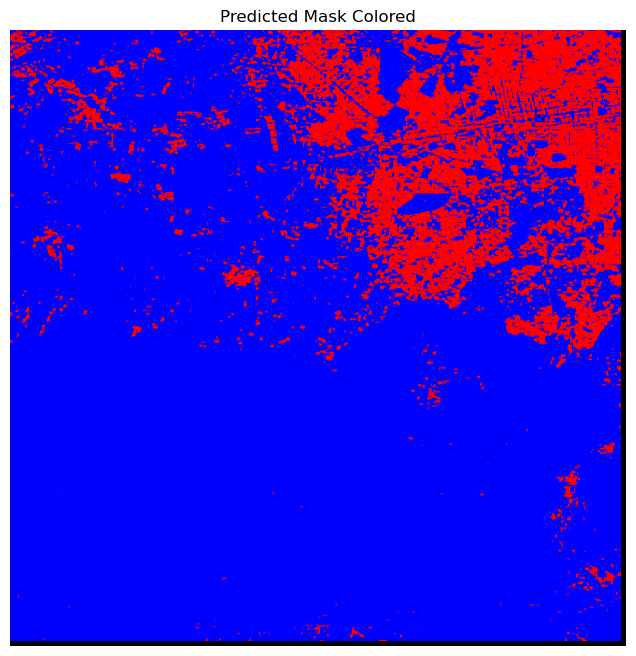

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Define the colormap
colormap = np.array([
    [0, 0, 0],       # Formal
    [0, 0, 255],     # Other Background
    [255, 0, 0],     # Informal
], dtype=np.uint8)

color_mask = colormap[predicted_mask]

plt.figure(figsize=(8, 8))
plt.imshow(color_mask)
plt.title("Predicted Mask Colored")
plt.axis('off')
plt.show()
